<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_AI_PRAC_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Feed Forward Backpropagation Neural Network
 Implement the Feed Forward Backpropagation algorithm to train a neural
network.
 Use a given dataset to train the neural network for a specific task.
 Evaluate the performance of the trained network on test data.

Saving iris.csv to iris (1).csv
Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Test Accuracy: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


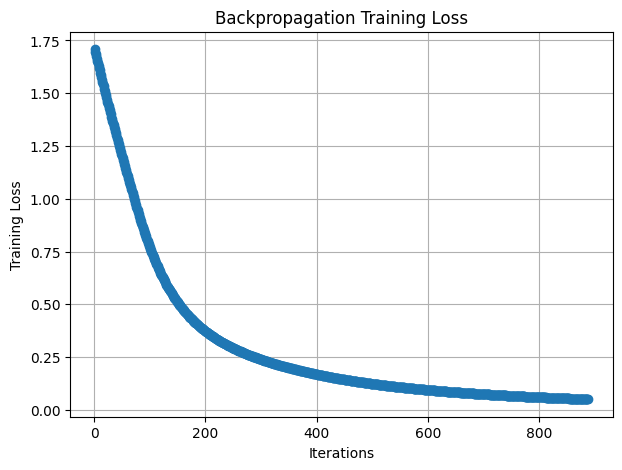

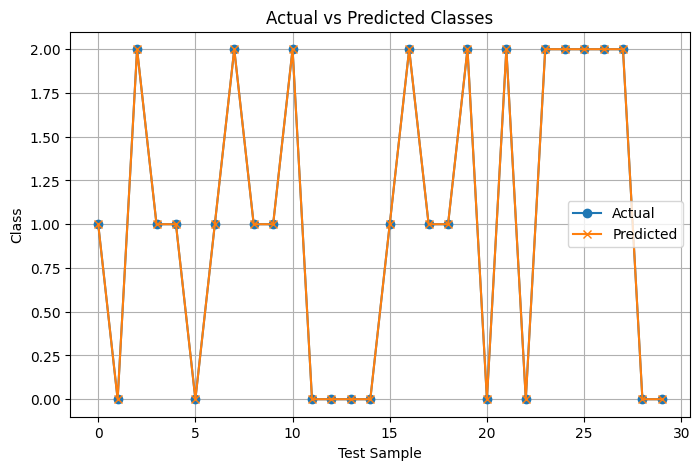

In [ ]:
# Feed Forward Backpropagation Neural Network

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Upload CSV file
uploaded = files.upload()

# Load dataset
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Dataset:")
print(data.head())

# Input and output
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Convert categorical input columns
X = pd.get_dummies(X)

# Convert output into numbers
if y.dtype == 'object':
    encoder = LabelEncoder()
    y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feed Forward Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ---------------- GRAPH 1 ----------------

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(model.loss_curve_) + 1),
    model.loss_curve_,
    marker='o'
)

plt.xlabel("Iterations")
plt.ylabel("Training Loss")
plt.title("Backpropagation Training Loss")
plt.grid(True)
plt.show()


# ---------------- GRAPH 2 ----------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(y_test)),
    y_test,
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='x',
    label='Predicted'
)

plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()